# Read Data
1. Load the cleaned dataset and reuse the existing train/test split
2. Reuse the pre-defined 80/20 split instead of re-splitting randomly.
3. Produce train_df and test_df containing full rows for the selected sequences.

In [1]:
import numpy as np
import pandas as pd

from pathlib import Path
REPO_ROOT = Path.cwd().parent.parent
PROCESSED_DIR = REPO_ROOT / "data" / "processed"

print("REPO_ROOT =", REPO_ROOT)
print("PROCESSED_DIR =", PROCESSED_DIR)

# ---- 1) Read final processed
data_path = PROCESSED_DIR / "final_processed_data.parquet"
df = pd.read_parquet(data_path)

print("Loaded:", data_path)
print("df shape:", df.shape)
print(df.head(2))

REPO_ROOT = E:\A1_last_version
PROCESSED_DIR = E:\A1_last_version\data\processed
Loaded: E:\A1_last_version\data\processed\final_processed_data.parquet
df shape: (536115, 341)
              row_id sequence_type sequence_id  sequence_counter      subject  \
0  SEQ_000007_000000        Target  SEQ_000007                 0  SUBJ_059520   
1  SEQ_000007_000001        Target  SEQ_000007                 1  SUBJ_059520   

                       orientation                                   behavior  \
0  Seated Lean Non Dom - FACE DOWN  Relaxes and moves hand to target location   
1  Seated Lean Non Dom - FACE DOWN  Relaxes and moves hand to target location   

        phase             gesture     acc_x  ...  tof_5_v54  tof_5_v55  \
0  Transition  Cheek - pinch skin  6.683594  ...       -1.0       -1.0   
1  Transition  Cheek - pinch skin  6.949219  ...       -1.0       -1.0   

   tof_5_v56  tof_5_v57  tof_5_v58  tof_5_v59  tof_5_v60  tof_5_v61  \
0       -1.0       -1.0       -1.0       -

# Preclean data + train/test split (sequence)

In [2]:
SEQ_COL = "sequence_id"
LABEL_COL = "gesture"

if LABEL_COL not in df.columns:
    if "behavior" in df.columns:
        LABEL_COL = "behavior"
    elif "label" in df.columns:
        LABEL_COL = "label"
    else:
        raise KeyError("cannot find gesture/behavior/label，please check df.columns")

# Name：acc_x, rot_w, thm_1, tof_...
imu_cols = [c for c in df.columns if c.startswith("acc_") or c.startswith("rot_")]
thm_cols = [c for c in df.columns if c.startswith("thm_")]
tof_cols = [c for c in df.columns if c.startswith("tof_")]

all_cols = imu_cols + thm_cols + tof_cols

print("IMU cols:", len(imu_cols))
print("THM cols:", len(thm_cols))
print("TOF cols:", len(tof_cols))
print("ALL cols:", len(all_cols))

df2 = df.dropna(subset=all_cols + [SEQ_COL, LABEL_COL]).copy()
print("After dropna:", df2.shape)

seq_len = df2.groupby(SEQ_COL).size()
thr = seq_len.mean() - seq_len.std()
keep_sids = seq_len[seq_len >= thr].index
df2 = df2[df2[SEQ_COL].isin(keep_sids)].copy()

print("Sequence length mean:", float(seq_len.mean()), "std:", float(seq_len.std()), "threshold:", float(thr))
print("After short-seq filter:", df2.shape)
print("Num sequences:", df2[SEQ_COL].nunique())

rng = np.random.default_rng(42)
sids = df2[SEQ_COL].unique()
rng.shuffle(sids)
cut = int(len(sids) * 0.8)
tr_ids = set(sids[:cut])
te_ids = set(sids[cut:])
train_df = df2[df2[SEQ_COL].isin(tr_ids)].copy()
test_df  = df2[df2[SEQ_COL].isin(te_ids)].copy()
split_mode = "random(80/20 by sequence, seed=42)"

print("Split mode:", split_mode)
print("Train sequences:", train_df[SEQ_COL].nunique(), "Test sequences:", test_df[SEQ_COL].nunique())


IMU cols: 7
THM cols: 5
TOF cols: 320
ALL cols: 332
After dropna: (536115, 341)
Sequence length mean: 70.65300474433316 std: 35.80745221380583 threshold: 34.84555253052733
After short-seq filter: (536115, 341)
Num sequences: 7588
Split mode: random(80/20 by sequence, seed=42)
Train sequences: 6070 Test sequences: 1518


# Identify sensor columns (IMU / THM / TOF)
1. Then concatenate all columns as the "all sensors" input for Model 6
2. A typical TOF setup is 5 sensors × 8×8 = 320 features per timestep

In [3]:
imu_cols = sorted([c for c in df.columns if c.startswith("acc_") or c.startswith("rot_")])
thm_cols = sorted([c for c in df.columns if c.startswith("thm_")])
tof_cols = sorted([c for c in df.columns if c.startswith("tof_")])

all_cols = imu_cols + thm_cols + tof_cols

print("IMU:", len(imu_cols), "THM:", len(thm_cols), "TOF:", len(tof_cols))
print("All sensor cols:", len(all_cols))

if len(tof_cols) != 320:
    print("Warning: TOF cols != 320 (got", len(tof_cols), ")")


IMU: 7 THM: 5 TOF: 320
All sensor cols: 332


# Build FFT features per sequence (sequence-level feature vector)

In [4]:
K_FREQ = 32

def seq_label_majority(seq_df):
    return seq_df[LABEL_COL].value_counts().idxmax()

def fft_vectorize_sequence(seq_df, cols, k_freq):
    X = seq_df[cols].to_numpy(dtype=np.float32)
    F = np.fft.rfft(X, axis=0)
    mag = np.abs(F).astype(np.float32)

    if mag.shape[0] >= k_freq:
        mag = mag[:k_freq, :]
    else:
        pad = np.zeros((k_freq - mag.shape[0], mag.shape[1]), dtype=np.float32)
        mag = np.vstack([mag, pad])

    return mag.reshape(-1)

def build_rf_dataset(df_points, cols, k_freq):
    X_list, y_list, sid_list = [], [], []
    for sid, g in df_points.groupby(SEQ_COL):
        X_list.append(fft_vectorize_sequence(g, cols, k_freq))
        y_list.append(seq_label_majority(g))
        sid_list.append(sid)
    return np.vstack(X_list), np.array(y_list), np.array(sid_list)

Xtr, ytr, sid_tr = build_rf_dataset(train_df, all_cols, K_FREQ)
Xte, yte, sid_te = build_rf_dataset(test_df,  all_cols, K_FREQ)

print("Xtr:", Xtr.shape, "Xte:", Xte.shape)
print("Num classes in train:", len(np.unique(ytr)))


Xtr: (6070, 10624) Xte: (1518, 10624)
Num classes in train: 18


# Train the Random Forest classifier (Model 6)
Paper-aligned RF configuration:
- n_estimators = 100 (100 trees)
- max_depth = None  (unlimited depth)
- majority voting is the default RF decision rule

In [5]:
import json
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# ----------------------------
# 0) Train RF (paper-aligned)
# ----------------------------
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)
rf.fit(Xtr, ytr)

# ----------------------------
# 1) Predict
# ----------------------------
pred_mc = rf.predict(Xte)

# ----------------------------
# 2) Build label strings (IMPORTANT)
# ----------------------------
BFRB_LABELS = [
    "Above ear - pull hair",
    "Cheek - pinch skin",
    "Eyebrow - pull hair",
    "Eyelash - pull hair",
    "Forehead - pull hairline",
    "Forehead - scratch",
    "Neck - pinch skin",
    "Neck - scratch",
]
bfrb_set = set(BFRB_LABELS)

# Case A: yte is already string labels
if isinstance(yte[0], str):
    y_true_str = np.array(yte, dtype=object)
    y_pred_str = np.array(pred_mc, dtype=object)

# Case B: yte is int labels -> convert to string labels
else:
   

    raise ValueError("yte is int labels. Please uncomment one mapping (le or idx2label).")

# ----------------------------
# 3) Metrics
# ----------------------------
y_true_bin = np.array([1 if s in bfrb_set else 0 for s in y_true_str], dtype=int)
y_pred_bin = np.array([1 if s in bfrb_set else 0 for s in y_pred_str], dtype=int)

acc = accuracy_score(yte, pred_mc)
macro_f1 = f1_score(yte, pred_mc, average="macro")
binary_f1 = f1_score(y_true_bin, y_pred_bin)

print(f"Accuracy          : {acc:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")
print(f"Binary F1         : {binary_f1:.4f}")
print(f"True positive rate: {y_true_bin.mean():.4f}")
print(f"Pred positive rate: {y_pred_bin.mean():.4f}")

# ----------------------------
# 4) Save JSON
# ----------------------------
metrics_output = {
    "final_metrics": {
        "acc": float(acc),
        "macroF1": float(macro_f1),
        "binaryF1": float(binary_f1)
    }
}

results_dir = REPO_ROOT / "results" / "Model6_Training"
results_dir.mkdir(parents=True, exist_ok=True)

json_path = results_dir / "model6_training_summary.json"

# If file exists, delete first (avoids Windows lock issues sometimes)
if json_path.exists():
    json_path.unlink()

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(metrics_output, f, indent=4)

print("Saved JSON to:", json_path)


Accuracy          : 0.4190
Macro F1          : 0.3716
Binary F1         : 0.8926
True positive rate: 0.6304
Pred positive rate: 0.6640
Saved JSON to: E:\A1_last_version\results\Model6_Training\model6_training_summary.json


# Plots: metrics bar + confusion matrix (saved to REPO_ROOT/plots)

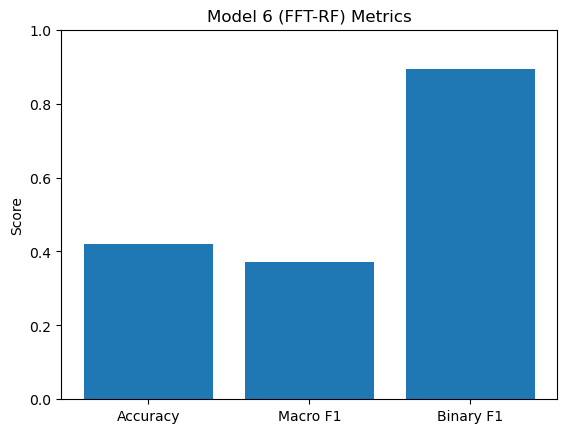

<Figure size 1000x1000 with 0 Axes>

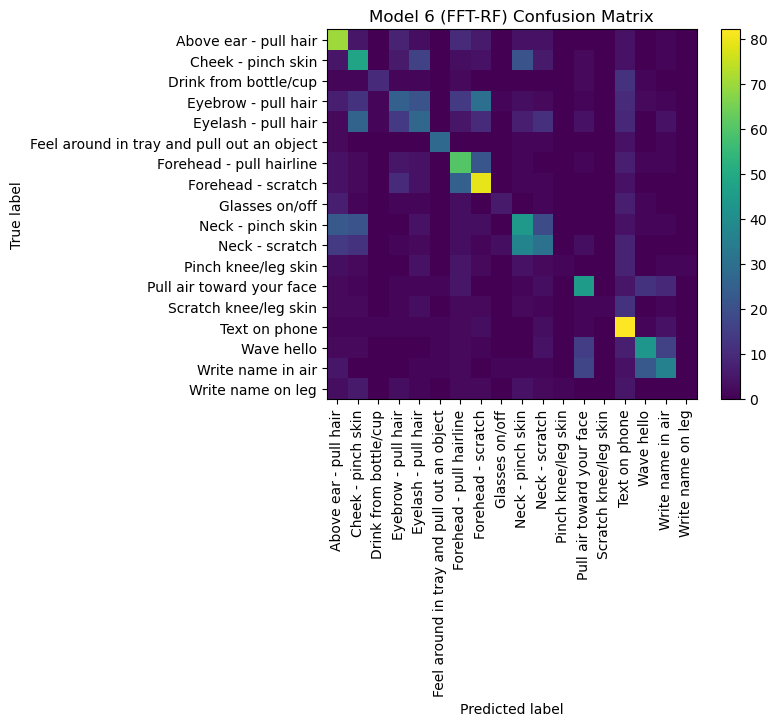

Saved plots to: E:\A1_last_version\plots\Model 6 FFT–Random Forest


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from pathlib import Path
PLOTS_DIR = REPO_ROOT / "plots"/"Model 6 FFT–Random Forest"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# 1) Metrics bar chart
plt.figure()
plt.bar(["Accuracy", "Macro F1", "Binary F1"], [acc, macro_f1, binary_f1])
plt.ylim(0, 1)
plt.title("Model 6 (FFT-RF) Metrics")
plt.ylabel("Score")
plt.savefig(PLOTS_DIR / "model6_metrics.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# 2) Confusion matrix (multi-class)
labels_sorted = sorted(np.unique(np.concatenate([yte, pred_mc])))
cm = confusion_matrix(yte, pred_mc, labels=labels_sorted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_sorted)

plt.figure(figsize=(10, 10))
disp.plot(include_values=False, xticks_rotation=90)
plt.title("Model 6 (FFT-RF) Confusion Matrix")
plt.savefig(PLOTS_DIR / "model6_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved plots to:", PLOTS_DIR)